In [13]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import random
from openpyxl import load_workbook
from numba import jit

In [43]:
# Define the boundary and well radius
l = 4.0
r_out = 0.9
r_in = 0.1     #well radius
b = r_out
depth=0         #depth=0:original Try different depth values
w_h = 9.0 + depth   #well height
cap = 9.0 + depth   #cap height
fps = 10000
# Define the diffusion coefficient and beta value
r_bead = 0.1
D_0 = 1.005
r_0 = 0.1
k = D_0*r_0
D = k/r_bead
beta = 3.0
epsilon = 0.9

# Define the step size and the total simulation time
dx = dy = dz = 0.04

# Choose the excel file to save data
path = "./Excel/"+str(D)+'_'+str(fps)+'Hz_depth='+str(depth)+'step_size='+str(dx)+'_angle_restart_rim_epsilon='+str(epsilon)+'.xlsx'
print(path)


./Excel/1.005_10000Hz_depth=0step_size=0.04_angle_restart_rim_epsilon=0.9.xlsx


Text(0.5, 1.0, 'Geometric well')

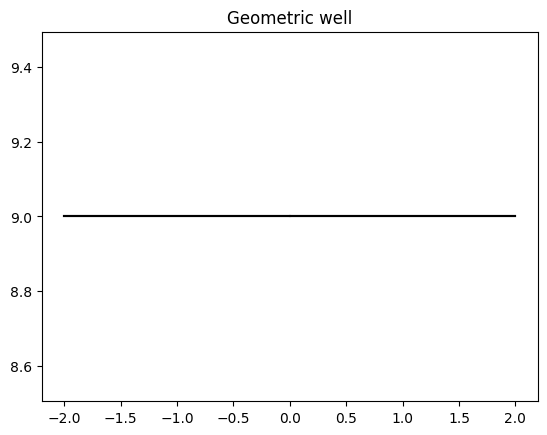

In [44]:
import warnings
# Well
@jit(nopython=True)
def well_z(r):  
    return (r >= 0)*w_h
@jit(nopython=True)
def well_r(z_pos):
    return r_out
r_span= np.linspace(0, l//2, 100)
z_span= np.linspace(0, w_h, 100)
plt.plot(r_span,well_z(r_span),color="black")
plt.plot(-r_span,well_z(r_span),color="black")
plt.plot([-l//2,l//2],[cap,cap],color="black")
plt.title("Geometric well")
#plt.plot(z_span,well_r(z_span))

Maximum dwell time at log10(t) = -0.8894618072532053


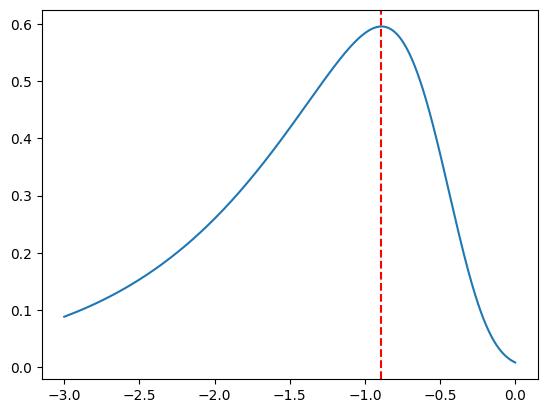

In [45]:
from scipy.special import jn_zeros
n=100
jn_zero = jn_zeros(0, n)
def dwell(t):
    return 4*np.sum(np.exp(-jn_zero[None,:]**2*t[:,None]),axis=1)
unit= r_out**2/D
t=np.linspace(0.001, 1, 10000)
x=np.log10(t)
y=dwell(t/unit)/unit*t*np.log(10)
x_max=x[np.argmax(y)]
print("Maximum dwell time at log10(t) =", x_max)
plt.plot(x,y , label="Dwell time")
plt.axvline(x_max, color='red', linestyle='--', label='Max dwell time')

In [ ]:
import tqdm
import time
np.random.seed(seed=0)
# Define the position arrays for analysis

# Repeat the Gillespie Algorithm for N steps
@jit(nopython=True)
def shift(x):
    l=2
    return (x+l)%(2*l)-l
@jit(nopython=True)
def Gillispie_wander(L_max=10**5):
    #steps=10**5
    #x_track,y_track,z_track,t_track=np.zeros((4,steps))
    np.random.seed(seed=0)
    # Calculate a(v) for v = [0,6]
    a_v = D/dx**2
    a0 = a_v*6

    # Define the initial state of the nanoparticle
    r=np.random.uniform(low=0.0, high=r_out)
    theta=np.random.uniform(low=0.0, high=2*np.pi)
    z_min= well_z(r)
    x = r*np.cos(theta)
    y = r*np.sin(theta)
    z = np.random.uniform(low=z_min, high=cap)
    t = 0.0
    radius = np.sqrt(x**2+y**2)
    #x_track[0],y_track[0],z_track[0],t_track[0]=x,y,z,t

    # IN = 1, OUT = 0
    if radius<=r_out:
        prev_in_well=1
    else:
        prev_in_well=0
    dwell_track=np.zeros((L_max))
    x_frame,y_frame,z_frame,t_frame=[x,x],[y,y],[z,z],[t,t]
    Z=[]
    enter_track,leave_track,angle_track=np.zeros((L_max,2)),np.zeros((L_max,2)),np.zeros((L_max))
    i=1
    L=0
    l=2
    while(L<L_max-1):
        x_frame,y_frame,z_frame,t_frame=[x_frame[-2],x_frame[-1]],[y_frame[-2],y_frame[-1]],[z_frame[-2],z_frame[-1]],[t_frame[-2],t_frame[-1]]
        while t < i/fps:
            # Generate 2 random number
            r1, r2 = np.random.uniform(low=0.0, high=1.0,size=2)

            # Calculate the time for movement
            tau = 1/a0*np.log(1/r1)

            # Choose the direction of the jump
            k = 1
            diff = r2*a0 - a_v

            while diff >= 0:
                k = k + 1
                diff = diff - a_v

            next_event = k

            # Update the position arrays
            if k == 1 and z >= w_h:
                x = x + dx
                t = t + tau
                x_frame.append(x),y_frame.append(y),z_frame.append(z),t_frame.append(t)
            elif k == 2 and z >= w_h:
                x = x - dx
                t = t + tau
                x_frame.append(x),y_frame.append(y),z_frame.append(z),t_frame.append(t)
            elif k == 3 and z >= w_h:
                y = y + dy
                t = t + tau
                x_frame.append(x),y_frame.append(y),z_frame.append(z),t_frame.append(t)
            elif k == 4 and z >= w_h:
                y = y - dy
                t = t + tau
                x_frame.append(x),y_frame.append(y),z_frame.append(z),t_frame.append(t)
            elif k == 5 and z+dz <= cap:
                z = z + dz
                t = t + tau
                x_frame.append(x),y_frame.append(y),z_frame.append(z),t_frame.append(t)
            elif k == 6 and z-dz >= w_h:
                z = z - dz
                t = t + tau
                x_frame.append(x),y_frame.append(y),z_frame.append(z),t_frame.append(t)
        x_frame.append((x_frame[-1]*(i/fps-t_frame[-2])+x_frame[-2]*(t_frame[-1]-i/fps))/(t_frame[-1]-t_frame[-2]))
        y_frame.append((y_frame[-1]*(i/fps-t_frame[-2])+y_frame[-2]*(t_frame[-1]-i/fps))/(t_frame[-1]-t_frame[-2]))
        z_frame.append((z_frame[-1]*(i/fps-t_frame[-2])+z_frame[-2]*(t_frame[-1]-i/fps))/(t_frame[-1]-t_frame[-2]))
        t_frame.append(i/fps)
        x_frame[-2],x_frame[-1]=x_frame[-1],x_frame[-2]
        y_frame[-2],y_frame[-1]=y_frame[-1],y_frame[-2]
        z_frame[-2],z_frame[-1]=z_frame[-1],z_frame[-2]
        t_frame[-2],t_frame[-1]=t_frame[-1],t_frame[-2]
        avg_x=np.trapz(x_frame[:-1],x=t_frame[:-1])/(1/fps)
        avg_y=np.trapz(y_frame[:-1],x=t_frame[:-1])/(1/fps)
        avg_z=np.trapz(z_frame[:-1],x=t_frame[:-1])/(1/fps)
        radius = np.sqrt(((avg_x+2.0)%(4.0)-2.0)**2+((avg_y+2.0)%(4.0)-2.0)**2)
        Z.append(avg_z)
        #x_track[i],y_track[i],z_track[i],t_track[i]=avg_x,avg_y,avg_z,i/fps
        
        # IN = 1, OUT = 0
        if radius <= r_out:
            if prev_in_well==0:
                L+=1
                enter_track[L]=shift(np.array([avg_x,avg_y]))
            dwell_track[L]+=1/fps
            prev_in_well=1
        else:
            if prev_in_well==1:
                leave_track[L]=shift(np.array([avg_x,avg_y]))
                angle_track[L]=np.abs(np.arctan2(leave_track[L,1],leave_track[L,0])-np.arctan2(enter_track[L,1],enter_track[L,0]))
            prev_in_well=0
        i=i+1
    return dwell_track,angle_track,Z
start_time=time.time()
dwell_track,angle_track,z=Gillispie_wander(L_max=10**5)
end_time=time.time()
print(end_time-start_time)

In [ ]:
import tqdm
import time
np.random.seed(seed=0)
# Define the position arrays for analysis

# Repeat the Gillespie Algorithm for N steps
@jit(nopython=True)
def shift(x):
    l=2
    return (x+l)%(2*l)-l
@jit(nopython=True)
def Gillispie_restart(L_max=10**3):
    #steps=10**5
    #x_track,y_track,z_track,t_track=np.zeros((4,steps))
    np.random.seed(seed=0)
    # Calculate a(v) for v = [0,6]
    a_v = D/dx**2
    a0 = a_v*6
    # Define the initial state of the nanoparticle
    r=np.random.uniform(low=0.0, high=r_out)
    theta=np.random.uniform(low=0.0, high=2*np.pi)
    z_min= well_z(r)
    x = r*np.cos(theta)
    y = r*np.sin(theta)
    z = np.random.uniform(low=z_min, high=cap)
    t = 0.0
    dwell_track=np.zeros(L_max)
    i=1
    L=0
    l=2
    while(L<L_max-1):
        r1, r2 = np.random.uniform(low=0.0, high=1.0,size=2)

        # Calculate the time for movement
        tau = 1/a0*np.log(1/r1)

        # Choose the direction of the jump
        k = 1
        diff = r2*a0 - a_v

        while diff >= 0:
            k = k + 1
            diff = diff - a_v

        next_event = k

        # Update the position arrays
        if k == 1 and ((round(((x+dx+2.0)%(4.0)-2.0),2)**2+round(((y+2.0)%(4.0)-2.0),2)**2) <= (well_r(z))**2 or z >= w_h):
            x = x + dx
            t = t + tau
            
        elif k == 2 and ((round(((x-dx+2.0)%(4.0)-2.0),2)**2+round(((y+2.0)%(4.0)-2.0),2)**2) <= (well_r(z))**2 or z >= w_h):
            x = x - dx
            t = t + tau
            
        elif k == 3 and ((round(((x+2.0)%(4.0)-2.0),2)**2+round(((y+dy+2.0)%(4.0)-2.0),2)**2) <= (well_r(z))**2 or z >= w_h):
            y = y + dy
            t = t + tau
            
        elif k == 4 and ((round(((x+2.0)%(4.0)-2.0),2)**2+round(((y-dy+2.0)%(4.0)-2.0),2)**2) <= (well_r(z))**2 or z >= w_h):
            y = y - dy
            t = t + tau
            
        elif k == 5 and z+dz <= cap:
            z = z + dz
            t = t + tau
            
        elif k == 6 and z-dz >= well_z(np.sqrt(round(((x+2.0)%(4.0)-2.0),2)**2+round(((y+2.0)%(4.0)-2.0),2)**2)):
            z = z - dz
            t = t + tau

        radius = np.sqrt(((x+2.0)%(4.0)-2.0)**2+((y+2.0)%(4.0)-2.0)**2)
        # IN = 1, OUT = 0
        if radius <= r_out:
            dwell_track[L]+=tau
        else:
            L+=1
            r=np.random.uniform(low=0.0, high=r_out)
            theta=np.random.uniform(low=0.0, high=2*np.pi)
            z_min= well_z(r)
            x = r*np.cos(theta)
            y = r*np.sin(theta)
            z = np.random.uniform(low=z_min, high=cap)
        i=i+1
        print(L)
    return dwell_track
start_time=time.time()
dwell_track=Gillispie_restart(L_max=10**3)
end_time=time.time()
print(end_time-start_time)

In [ ]:
import tqdm
import time
np.random.seed(seed=0)
# Define the position arrays for analysis

# Repeat the Gillespie Algorithm for N steps
@jit(nopython=True)
def shift(x):
    l=2
    return (x+l)%(2*l)-l
@jit(nopython=True)
def Gillispie_restart(L_max=10**5):
    #steps=10**5
    #x_track,y_track,z_track,t_track=np.zeros((4,steps))
    np.random.seed(seed=0)
    # Calculate a(v) for v = [0,6]
    a_v = D/dx**2
    a0 = a_v*6
    # Define the initial state of the nanoparticle
    r=np.random.uniform(low=0.0, high=r_out)
    theta=np.random.uniform(low=0.0, high=2*np.pi)
    z_min= well_z(r)
    x = r*np.cos(theta)
    y = r*np.sin(theta)
    z = np.random.uniform(low=z_min, high=cap)
    t = 0.0
    dwell_track=np.zeros(L_max)
    x_frame,y_frame,z_frame,t_frame=[x,x],[y,y],[z,z],[t,t]
    Z=[]
    enter_track,leave_track,angle_track=np.zeros((L_max,2)),np.zeros((L_max,2)),np.zeros((L_max))
    i=1
    L=0
    l=2
    while(L<L_max-1):
        x_frame,y_frame,z_frame,t_frame=[x_frame[-2],x_frame[-1]],[y_frame[-2],y_frame[-1]],[z_frame[-2],z_frame[-1]],[t_frame[-2],t_frame[-1]]
        while t < i/fps:
            # Generate 2 random number
            r1, r2 = np.random.uniform(low=0.0, high=1.0,size=2)

            # Calculate the time for movement
            tau = 1/a0*np.log(1/r1)

            # Choose the direction of the jump
            k = 1
            diff = r2*a0 - a_v

            while diff >= 0:
                k = k + 1
                diff = diff - a_v

            next_event = k

            # Update the position arrays
            if k == 1 and z >= w_h:
                x = x + dx
                t = t + tau
                x_frame.append(x),y_frame.append(y),z_frame.append(z),t_frame.append(t)
            elif k == 2 and z >= w_h:
                x = x - dx
                t = t + tau
                x_frame.append(x),y_frame.append(y),z_frame.append(z),t_frame.append(t)
            elif k == 3 and z >= w_h:
                y = y + dy
                t = t + tau
                x_frame.append(x),y_frame.append(y),z_frame.append(z),t_frame.append(t)
            elif k == 4 and z >= w_h:
                y = y - dy
                t = t + tau
                x_frame.append(x),y_frame.append(y),z_frame.append(z),t_frame.append(t)
            elif k == 5 and z+dz <= cap:
                z = z + dz
                t = t + tau
                x_frame.append(x),y_frame.append(y),z_frame.append(z),t_frame.append(t)
            elif k == 6 and z-dz >= w_h:
                z = z - dz
                t = t + tau
                x_frame.append(x),y_frame.append(y),z_frame.append(z),t_frame.append(t)
        x_frame.append((x_frame[-1]*(i/fps-t_frame[-2])+x_frame[-2]*(t_frame[-1]-i/fps))/(t_frame[-1]-t_frame[-2]))
        y_frame.append((y_frame[-1]*(i/fps-t_frame[-2])+y_frame[-2]*(t_frame[-1]-i/fps))/(t_frame[-1]-t_frame[-2]))
        z_frame.append((z_frame[-1]*(i/fps-t_frame[-2])+z_frame[-2]*(t_frame[-1]-i/fps))/(t_frame[-1]-t_frame[-2]))
        t_frame.append(i/fps)
        x_frame[-2],x_frame[-1]=x_frame[-1],x_frame[-2]
        y_frame[-2],y_frame[-1]=y_frame[-1],y_frame[-2]
        z_frame[-2],z_frame[-1]=z_frame[-1],z_frame[-2]
        t_frame[-2],t_frame[-1]=t_frame[-1],t_frame[-2]
        avg_x=np.trapz(x_frame[:-1],x=t_frame[:-1])/(1/fps)
        avg_y=np.trapz(y_frame[:-1],x=t_frame[:-1])/(1/fps)
        avg_z=np.trapz(z_frame[:-1],x=t_frame[:-1])/(1/fps)
        radius = np.sqrt(((avg_x+2.0)%(4.0)-2.0)**2+((avg_y+2.0)%(4.0)-2.0)**2)
        Z.append(avg_z)
        #x_track[i],y_track[i],z_track[i],t_track[i]=avg_x,avg_y,avg_z,i/fps
        if radius <= r_out:
            dwell_track[L]+=1/fps
        else:
            L+=1
            leave_track[L]=shift(np.array([avg_x,avg_y]))
            angle_track[L]=np.abs(np.arctan2(leave_track[L,1],leave_track[L,0])-np.arctan2(enter_track[L,1],enter_track[L,0]))
            r=np.random.uniform(low=0.0, high=r_out)
            theta=np.random.uniform(low=0.0, high=2*np.pi)
            z_min= well_z(r)
            x = r*np.cos(theta)
            y = r*np.sin(theta)
            z = np.random.uniform(low=z_min, high=cap)
            enter_track[L]=shift(np.array([avg_x,avg_y]))
        i=i+1
        print(L)
    return dwell_track,angle_track,Z
start_time=time.time()
dwell_track,angle_track,z=Gillispie_restart(L_max=10**5)
end_time=time.time()
print(end_time-start_time)

In [46]:
import tqdm
import time
np.random.seed(seed=0)
# Define the position arrays for analysis

# Repeat the Gillespie Algorithm for N steps
@jit(nopython=True)
def shift(x):
    l=2
    return (x+l)%(2*l)-l
@jit(nopython=True)
def Gillispie_restart_rim_epsilon(L_max=10**5):
    #steps=10**5
    #x_track,y_track,z_track,t_track=np.zeros((4,steps))
    np.random.seed(seed=0)
    # Calculate a(v) for v = [0,6]
    a_v = D/dx**2
    a0 = a_v*6
    # Define the initial state of the nanoparticle
    e = epsilon
    r=np.random.uniform(low=r_out-e, high=r_out)
    theta=np.random.uniform(low=0.0, high=2*np.pi)
    z_min= well_z(r)
    x = r*np.cos(theta)
    y = r*np.sin(theta)
    z = np.random.uniform(low=z_min, high=cap)
    t = 0.0
    dwell_track=np.zeros(L_max)
    x_frame,y_frame,z_frame,t_frame=[x,x],[y,y],[z,z],[t,t]
    Z=[]
    enter_track,leave_track,angle_track=np.zeros((L_max,2)),np.zeros((L_max,2)),np.zeros((L_max))
    i=1
    L=0
    l=2
    while(L<L_max-1):
        x_frame,y_frame,z_frame,t_frame=[x_frame[-2],x_frame[-1]],[y_frame[-2],y_frame[-1]],[z_frame[-2],z_frame[-1]],[t_frame[-2],t_frame[-1]]
        while t < i/fps:
            # Generate 2 random number
            r1, r2 = np.random.uniform(low=0.0, high=1.0,size=2)

            # Calculate the time for movement
            tau = 1/a0*np.log(1/r1)

            # Choose the direction of the jump
            k = 1
            diff = r2*a0 - a_v

            while diff >= 0:
                k = k + 1
                diff = diff - a_v

            next_event = k

            # Update the position arrays
            if k == 1 and z >= w_h:
                x = x + dx
                t = t + tau
                x_frame.append(x),y_frame.append(y),z_frame.append(z),t_frame.append(t)
            elif k == 2 and z >= w_h:
                x = x - dx
                t = t + tau
                x_frame.append(x),y_frame.append(y),z_frame.append(z),t_frame.append(t)
            elif k == 3 and z >= w_h:
                y = y + dy
                t = t + tau
                x_frame.append(x),y_frame.append(y),z_frame.append(z),t_frame.append(t)
            elif k == 4 and z >= w_h:
                y = y - dy
                t = t + tau
                x_frame.append(x),y_frame.append(y),z_frame.append(z),t_frame.append(t)
            elif k == 5 and z+dz <= cap:
                z = z + dz
                t = t + tau
                x_frame.append(x),y_frame.append(y),z_frame.append(z),t_frame.append(t)
            elif k == 6 and z-dz >= w_h:
                z = z - dz
                t = t + tau
                x_frame.append(x),y_frame.append(y),z_frame.append(z),t_frame.append(t)
        x_frame.append((x_frame[-1]*(i/fps-t_frame[-2])+x_frame[-2]*(t_frame[-1]-i/fps))/(t_frame[-1]-t_frame[-2]))
        y_frame.append((y_frame[-1]*(i/fps-t_frame[-2])+y_frame[-2]*(t_frame[-1]-i/fps))/(t_frame[-1]-t_frame[-2]))
        z_frame.append((z_frame[-1]*(i/fps-t_frame[-2])+z_frame[-2]*(t_frame[-1]-i/fps))/(t_frame[-1]-t_frame[-2]))
        t_frame.append(i/fps)
        x_frame[-2],x_frame[-1]=x_frame[-1],x_frame[-2]
        y_frame[-2],y_frame[-1]=y_frame[-1],y_frame[-2]
        z_frame[-2],z_frame[-1]=z_frame[-1],z_frame[-2]
        t_frame[-2],t_frame[-1]=t_frame[-1],t_frame[-2]
        avg_x=np.trapz(x_frame[:-1],x=t_frame[:-1])/(1/fps)
        avg_y=np.trapz(y_frame[:-1],x=t_frame[:-1])/(1/fps)
        avg_z=np.trapz(z_frame[:-1],x=t_frame[:-1])/(1/fps)
        radius = np.sqrt(((avg_x+2.0)%(4.0)-2.0)**2+((avg_y+2.0)%(4.0)-2.0)**2)
        Z.append(avg_z)
        #x_track[i],y_track[i],z_track[i],t_track[i]=avg_x,avg_y,avg_z,i/fps
        if radius <= r_out:
            dwell_track[L]+=1/fps
        else:
            L+=1
            leave_track[L]=shift(np.array([avg_x,avg_y]))
            angle_track[L]=np.abs(np.arctan2(leave_track[L,1],leave_track[L,0])-np.arctan2(enter_track[L,1],enter_track[L,0]))
            r=np.random.uniform(low=r_out - e, high=r_out)
            theta=np.random.uniform(low=0.0, high=2*np.pi)
            z_min= well_z(r)
            x = r*np.cos(theta)
            y = r*np.sin(theta)
            z = np.random.uniform(low=z_min, high=cap)
            enter_track[L]=shift(np.array([avg_x,avg_y]))
        i=i+1
    return dwell_track,angle_track,Z
start_time=time.time()
dwell_track,angle_track,z=Gillispie_restart_rim_epsilon(L_max=10**5)
end_time=time.time()
print(end_time-start_time)

200.9848074913025


In [ ]:
import tqdm
import time
np.random.seed(seed=0)
# Define the position arrays for analysis

# Repeat the Gillespie Algorithm for N steps
@jit(nopython=True)
def shift(x):
    l=2
    return (x+l)%(2*l)-l
@jit(nopython=True)
def Gillispie_rim_epsilon(L_max=10**5):
   #steps=10**5
    #x_track,y_track,z_track,t_track=np.zeros((4,steps))
    np.random.seed(seed=0)
    # Calculate a(v) for v = [0,6]
    a_v = D/dx**2
    a0 = a_v*6
    # Define the initial state of the nanoparticle
    e = epsilon
    r=np.random.uniform(low=r_out-e, high=r_out)
    theta=np.random.uniform(low=0.0, high=2*np.pi)
    z_min= well_z(r)
    x = r*np.cos(theta)
    y = r*np.sin(theta)
    z = np.random.uniform(low=z_min, high=cap)
    t = 0.0
    dwell_track=np.zeros(L_max)
    x_frame,y_frame,z_frame,t_frame=[x,x],[y,y],[z,z],[t,t]
    Z=[]
    enter_track,leave_track,angle_track=np.zeros((L_max,2)),np.zeros((L_max,2)),np.zeros((L_max))
    i=1
    L=0
    l=2
    while(L<L_max-1):
        x_frame,y_frame,z_frame,t_frame=[x_frame[-2],x_frame[-1]],[y_frame[-2],y_frame[-1]],[z_frame[-2],z_frame[-1]],[t_frame[-2],t_frame[-1]]
        while t < i/fps:
            # Generate 2 random number
            r1, r2 = np.random.uniform(low=0.0, high=1.0,size=2)

            # Calculate the time for movement
            tau = 1/a0*np.log(1/r1)

            # Choose the direction of the jump
            k = 1
            diff = r2*a0 - a_v

            while diff >= 0:
                k = k + 1
                diff = diff - a_v

            next_event = k

            # Update the position arrays
            if k == 1 and ((round(((x+dx+2.0)%(4.0)-2.0),2)**2+round(((y+2.0)%(4.0)-2.0),2)**2) <= (well_r(z))**2 or z >= w_h):
                x = x + dx
                t = t + tau
                x_frame.append(x),y_frame.append(y),z_frame.append(z),t_frame.append(t)
            elif k == 2 and ((round(((x-dx+2.0)%(4.0)-2.0),2)**2+round(((y+2.0)%(4.0)-2.0),2)**2) <= (well_r(z))**2 or z >= w_h):
                x = x - dx
                t = t + tau
                x_frame.append(x),y_frame.append(y),z_frame.append(z),t_frame.append(t)
            elif k == 3 and ((round(((x+2.0)%(4.0)-2.0),2)**2+round(((y+dy+2.0)%(4.0)-2.0),2)**2) <= (well_r(z))**2 or z >= w_h):
                y = y + dy
                t = t + tau
                x_frame.append(x),y_frame.append(y),z_frame.append(z),t_frame.append(t)
            elif k == 4 and ((round(((x+2.0)%(4.0)-2.0),2)**2+round(((y-dy+2.0)%(4.0)-2.0),2)**2) <= (well_r(z))**2 or z >= w_h):
                y = y - dy
                t = t + tau
                x_frame.append(x),y_frame.append(y),z_frame.append(z),t_frame.append(t)
            elif k == 5 and z+dz <= cap:
                z = z + dz
                t = t + tau
                x_frame.append(x),y_frame.append(y),z_frame.append(z),t_frame.append(t)
            elif k == 6 and z-dz >= well_z(np.sqrt(round(((x+2.0)%(4.0)-2.0),2)**2+round(((y+2.0)%(4.0)-2.0),2)**2)):
                z = z - dz
                t = t + tau
                x_frame.append(x),y_frame.append(y),z_frame.append(z),t_frame.append(t)
        x_frame.append((x_frame[-1]*(i/fps-t_frame[-2])+x_frame[-2]*(t_frame[-1]-i/fps))/(t_frame[-1]-t_frame[-2]))
        y_frame.append((y_frame[-1]*(i/fps-t_frame[-2])+y_frame[-2]*(t_frame[-1]-i/fps))/(t_frame[-1]-t_frame[-2]))
        z_frame.append((z_frame[-1]*(i/fps-t_frame[-2])+z_frame[-2]*(t_frame[-1]-i/fps))/(t_frame[-1]-t_frame[-2]))
        t_frame.append(i/fps)
        x_frame[-2],x_frame[-1]=x_frame[-1],x_frame[-2]
        y_frame[-2],y_frame[-1]=y_frame[-1],y_frame[-2]
        z_frame[-2],z_frame[-1]=z_frame[-1],z_frame[-2]
        t_frame[-2],t_frame[-1]=t_frame[-1],t_frame[-2]
        avg_x=np.trapz(x_frame[:-1],x=t_frame[:-1])/(1/fps)
        avg_y=np.trapz(y_frame[:-1],x=t_frame[:-1])/(1/fps)
        avg_z=np.trapz(z_frame[:-1],x=t_frame[:-1])/(1/fps)
        radius = np.sqrt(((avg_x+2.0)%(4.0)-2.0)**2+((avg_y+2.0)%(4.0)-2.0)**2)
        Z.append(avg_z)
        #x_track[i],y_track[i],z_track[i],t_track[i]=avg_x,avg_y,avg_z,i/fps
        if radius <= r_out:
            dwell_track[L]+=1/fps
        else:
            L+=1
            leave_track[L]=shift(np.array([avg_x,avg_y]))
            angle_track[L]=np.abs(np.arctan2(leave_track[L,1],leave_track[L,0])-np.arctan2(enter_track[L,1],enter_track[L,0]))
            r=np.random.uniform(low=r_out-e, high=r_out)
            theta=np.random.uniform(low=0.0, high=2*np.pi)
            z_min= well_z(r)
            x = r*np.cos(theta)
            y = r*np.sin(theta)
            z = np.random.uniform(low=z_min, high=cap)
            enter_track[L]=shift(np.array([x,y]))
        i=i+1
    return dwell_track,angle_track,Z
start_time=time.time()
dwell_track,angle_track,z=Gillispie_rim_epsilon(L_max=10**5)
end_time=time.time()
print(end_time-start_time)

In [ ]:
import numpy as np
import pandas as pd
from openpyxl import load_workbook

In [47]:
with pd.ExcelWriter(path, engine='openpyxl') as writer:
	d = {'dwell_time': dwell_track[1:-1]}#,"angle":angle_track[1:-1]}
	df = pd.DataFrame(data = d)
	df.to_excel(writer, index = True, sheet_name = 'dwell time')

In [40]:
path0= './Excel/1.005_30Hz_depth=0step_size=0.04_angle_restart.xlsx'
data0 = pd.read_excel(path0, sheet_name='dwell time')

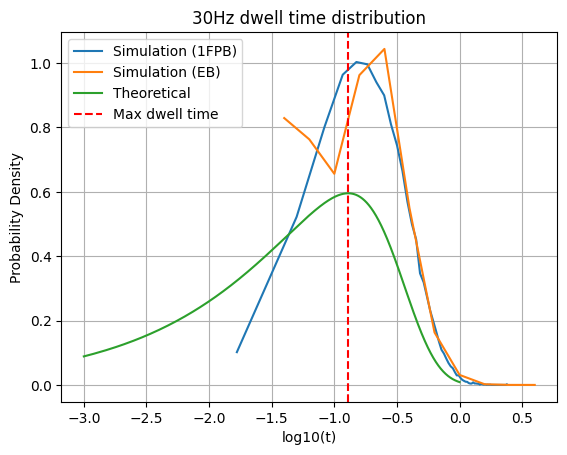

In [50]:
accuracy=10
Time0=data0['dwell_time']
bin_edge0=np.arange(0,np.max(Time0),1/30)
bin_center0 = (bin_edge0[:-1] + bin_edge0[1:]) / 2
hist0,bin0= np.histogram(np.round(Time0,decimals=accuracy), bins =np.round(bin_edge0,decimals=accuracy),density=True)
plt.plot(np.log10(bin_center0),bin_center0*hist0*np.log(10), label='Simulation (1FPB)')
bin_edge0=np.arange(-1.5,0.9,0.2)
bin_center0 = (bin_edge0[:-1] + bin_edge0[1:]) / 2
Time0=data0['dwell_time']
hist0,bin0= np.histogram(np.log10(Time0), bins = bin_edge0,density=True)
plt.plot(bin_center0,hist0, label='Simulation (EB)')
unit= r_out**2/D
t=np.linspace(0.001, 1, 10000)
x=np.log10(t)
y=dwell(t/unit)/unit*t*np.log(10)
plt.plot(x, y, label='Theoretical')
plt.title("30Hz dwell time distribution")
plt.xlabel("log10(t)")
plt.ylabel('Probability Density')
x_max=x[np.argmax(y)]
plt.axvline(x_max, color='red', linestyle='--', label='Max dwell time')
plt.grid()
plt.legend()

In [ ]:
path0 = './Excel/1.005_30Hz_depth=0step_size=0.04_angle_wander.xlsx'
data0 = pd.read_excel(path0, sheet_name='dwell time')
path1 = './Excel/1.005_60Hz_depth=0step_size=0.04_angle_wander.xlsx'
data1 = pd.read_excel(path1, sheet_name='dwell time')

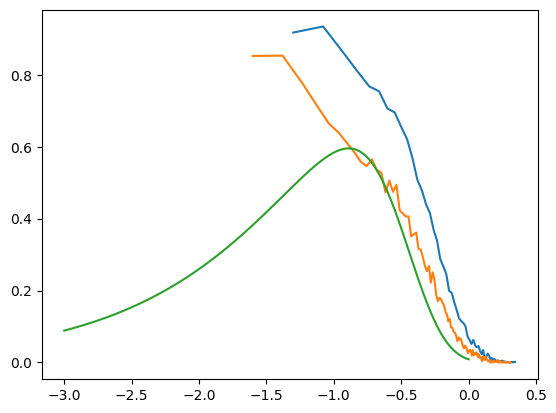

In [31]:
accuracy=6
Time0=data0['dwell_time']
bin_edge0=np.arange(1/30,np.max(Time0),1/30)
bin_center0 = (bin_edge0[:-1] + bin_edge0[1:]) / 2
hist0,bin0= np.histogram(np.round(Time0,decimals=accuracy), bins =np.round(bin_edge0,decimals=accuracy),density=True)
plt.plot(np.log10(bin_center0),bin_center0*hist0*np.log(10))
Time1=data1['dwell_time']
bin_edge1=np.arange(1/60,np.max(Time1),1/60)
bin_center1 = (bin_edge1[:-1] + bin_edge1[1:]) / 2
hist1,bin1= np.histogram(np.round(Time1,decimals=accuracy), bins =np.round(bin_edge1,decimals=accuracy),density=True)
plt.plot(np.log10(bin_center1),bin_center1*hist1*np.log(10))
unit= r_out**2/D
t=np.linspace(0.001, 1, 10000)
x=np.log10(t)
y=dwell(t/unit)/unit*t*np.log(10)
plt.plot(x, y)

C:\Users\85261\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\pandas\core\arraylike.py:399: RuntimeWarning: divide by zero encountered in log10
  result = getattr(ufunc, method)(*inputs, **kwargs)


"\nbin_edge1=np.arange(-1.8,0.9,0.2)\nbin_center1 = (bin_edge1[:-1] + bin_edge1[1:]) / 2\nTime1=data1['dwell_time']\nhist1,bin1= np.histogram(np.log10(Time1), bins = bin_edge1,density=True)\nplt.plot(bin_center1,hist1)\n"

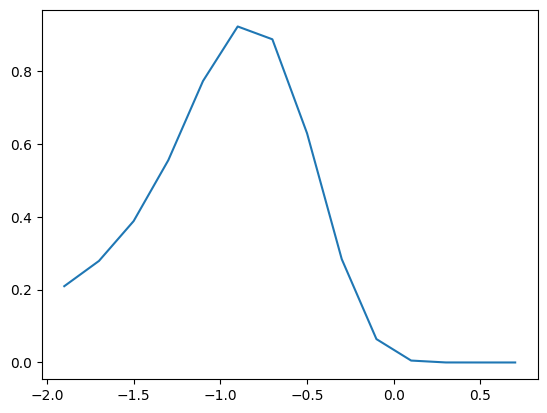

In [39]:
bin_edge0=np.arange(-2.0,0.9,0.2)
bin_center0 = (bin_edge0[:-1] + bin_edge0[1:]) / 2
Time0=data0['dwell_time']
hist0,bin0= np.histogram(np.log10(Time0), bins = bin_edge0,density=True)
plt.plot(bin_center0,hist0)
'''
bin_edge1=np.arange(-1.8,0.9,0.2)
bin_center1 = (bin_edge1[:-1] + bin_edge1[1:]) / 2
Time1=data1['dwell_time']
hist1,bin1= np.histogram(np.log10(Time1), bins = bin_edge1,density=True)
plt.plot(bin_center1,hist1)
'''

In [12]:
path0 = './Excel/1.005_30Hz_depth=0step_size=0.04_angle_wander.xlsx'
data0 = pd.read_excel(path0, sheet_name='dwell time')

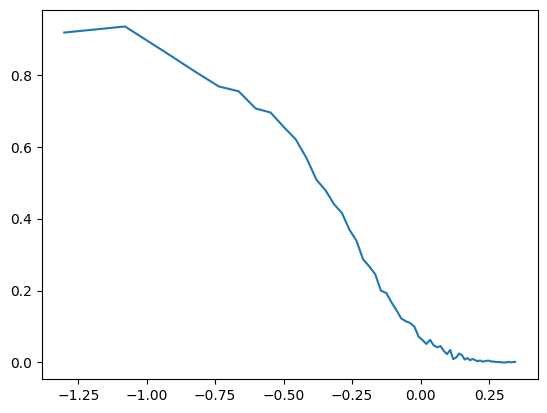

In [13]:
Time=data0['dwell_time']
bin_edge0=np.arange(1/30,np.max(Time),1/30)
bin_center0 = (bin_edge0[:-1] + bin_edge0[1:]) / 2
accuracy=10
hist0,bin0= np.histogram(np.round(Time,decimals=accuracy), bins = np.round(bin_edge0,decimals=accuracy), density = True)
plt.plot(np.log10(bin_center0),bin_center0*np.log(10)*hist0)

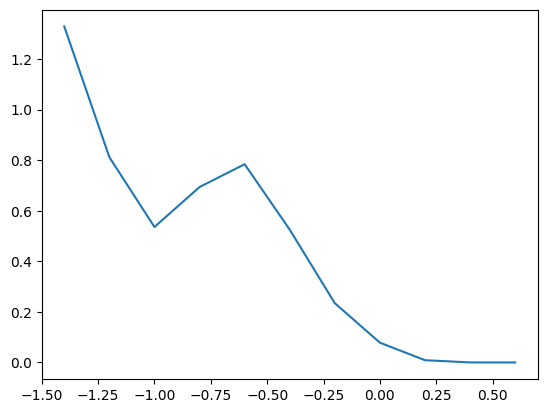

In [17]:
bin_edge0=np.arange(-1.5,0.9,0.2)
bin_center0 = (bin_edge0[:-1] + bin_edge0[1:]) / 2
Time=data0['dwell_time']
hist0,bin0= np.histogram(np.log10(Time), bins = bin_edge0,density=True)
plt.plot(bin_center0,hist0)

(99998,)


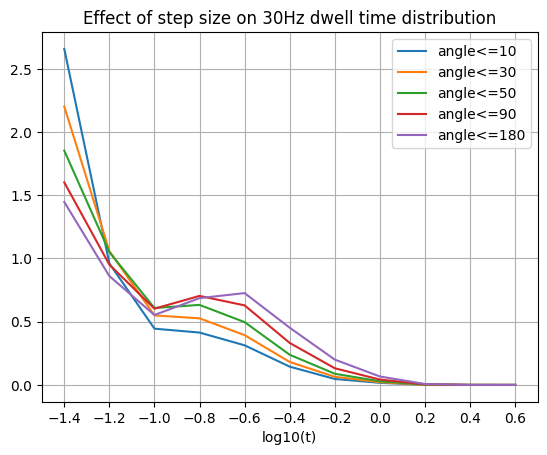

In [13]:
bin_edge1=np.arange(-1.5,0.9,0.2)
bin_center1 = (bin_edge1[:-1] + bin_edge1[1:]) / 2
Time=data0['dwell_time']
print(Time.shape)
angle=data0['angle']
angle_10=Time[angle<=10/180*np.pi]
angle_30=Time[angle<=30/180*np.pi]
angle_50=Time[angle<=50/180*np.pi]
angle_90=Time[angle<=90/180*np.pi]
angle_180=Time[angle<=180/180*np.pi]
#hist1,bin1= np.histogram(np.log10(data1['dwell_time']), bins = bin_edge1,density=True)
hist10,bin10= np.histogram(np.log10(angle_10), bins = bin_edge1,density=True)
hist30,bin30= np.histogram(np.log10(angle_30), bins = bin_edge1,density=True)
hist50,bin50= np.histogram(np.log10(angle_50), bins = bin_edge1,density=True)
hist90,bin90= np.histogram(np.log10(angle_90), bins = bin_edge1,density=True)
hist180,bin180= np.histogram(np.log10(angle_180), bins = bin_edge1,density=True)
plt.plot(bin_center1,hist10,label='angle<=10')
plt.plot(bin_center1,hist30,label='angle<=30')
plt.plot(bin_center1,hist50,label='angle<=50')
plt.plot(bin_center1,hist90,label='angle<=90')
plt.plot(bin_center1,hist180,label='angle<=180')
plt.title("Effect of step size on 30Hz dwell time distribution")
plt.xticks(bin_center1)
plt.xlabel("log10(t)")
plt.grid()
plt.legend()

(99998,)


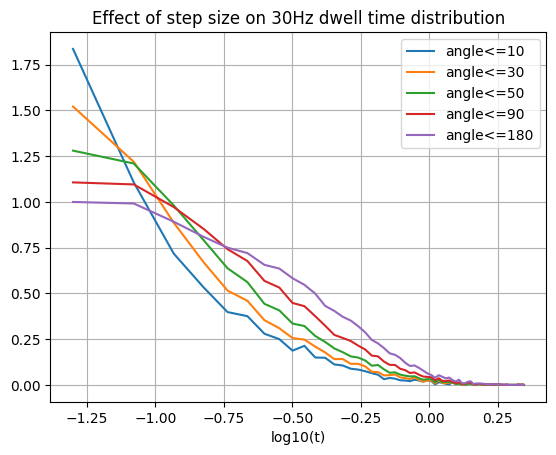

In [7]:
Time=data0['dwell_time']
print(Time.shape)
angle=data0['angle']
angle_10=Time[angle<=10/180*np.pi]
angle_30=Time[angle<=30/180*np.pi]
angle_50=Time[angle<=50/180*np.pi]
angle_90=Time[angle<=90/180*np.pi]
angle_180=Time[angle<=180/180*np.pi]
bin_edge0=np.arange(1/30,np.max(Time),1/30)
bin_center0 = (bin_edge0[:-1] + bin_edge0[1:]) / 2
accuracy=14
hist10,bin10= np.histogram(np.round(angle_10,decimals=accuracy), bins = np.round(bin_edge0,decimals=accuracy), density = True)
hist30,bin30= np.histogram(np.round(angle_30,decimals=accuracy), bins = np.round(bin_edge0,decimals=accuracy), density = True)
hist50,bin50= np.histogram(np.round(angle_50,decimals=accuracy), bins = np.round(bin_edge0,decimals=accuracy), density = True)
hist90,bin90= np.histogram(np.round(angle_90,decimals=accuracy), bins = np.round(bin_edge0,decimals=accuracy), density = True)
hist180,bin180= np.histogram(np.round(angle_180,decimals=accuracy), bins = np.round(bin_edge0,decimals=accuracy), density = True)
plt.plot(np.log10(bin_center0),bin_center0*np.log(10)*hist10,label='angle<=10')
plt.plot(np.log10(bin_center0),bin_center0*np.log(10)*hist30,label='angle<=30')
plt.plot(np.log10(bin_center0),bin_center0*np.log(10)*hist50,label='angle<=50')
plt.plot(np.log10(bin_center0),bin_center0*np.log(10)*hist90,label='angle<=90')
plt.plot(np.log10(bin_center0),bin_center0*np.log(10)*hist180,label='angle<=180')
plt.title("Effect of step size on 30Hz dwell time distribution")
plt.xlabel("log10(t)")
plt.grid()
plt.legend()

In [52]:
path0 = './Excel/1.005_30Hz_depth=0step_size=0.04_angle_restart_rim_epsilon=0.1.xlsx'
data0 = pd.read_excel(path0, sheet_name='dwell time')
path1 = './Excel/1.005_30Hz_depth=0step_size=0.04_angle_restart_rim_epsilon=0.2.xlsx'
data1 = pd.read_excel(path1, sheet_name='dwell time')
path2 = './Excel/1.005_30Hz_depth=0step_size=0.04_angle_restart_rim_epsilon=0.3.xlsx'
data2 = pd.read_excel(path2, sheet_name='dwell time')
path3 = './Excel/1.005_30Hz_depth=0step_size=0.04_angle_restart_rim_epsilon=0.4.xlsx'
data3 = pd.read_excel(path3, sheet_name='dwell time')
path4 = './Excel/1.005_30Hz_depth=0step_size=0.04_angle_restart_rim_epsilon=0.5.xlsx'
data4 = pd.read_excel(path4, sheet_name='dwell time')
path5 = './Excel/1.005_30Hz_depth=0step_size=0.04_angle_restart_rim_epsilon=0.6.xlsx'
data5 = pd.read_excel(path5, sheet_name='dwell time')
path6 = './Excel/1.005_30Hz_depth=0step_size=0.04_angle_restart_rim_epsilon=0.7.xlsx'
data6 = pd.read_excel(path6, sheet_name='dwell time')
path7 = './Excel/1.005_30Hz_depth=0step_size=0.04_angle_restart_rim_epsilon=0.8.xlsx'
data7 = pd.read_excel(path7, sheet_name='dwell time')
path8 = './Excel/1.005_30Hz_depth=0step_size=0.04_angle_restart.xlsx'
data8 = pd.read_excel(path8, sheet_name='dwell time')

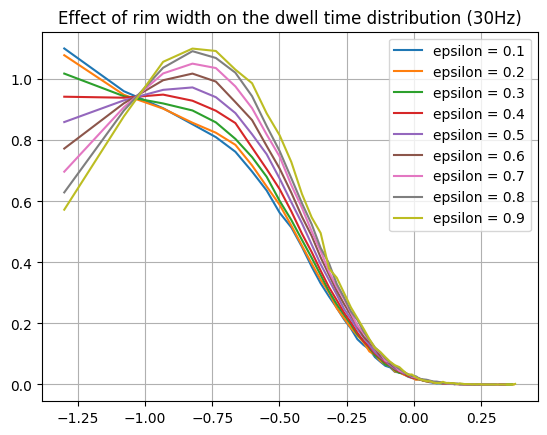

In [53]:
Time=data0['dwell_time']
bin_edge0=np.arange(1/30,np.max(Time),1/30)
bin_center0 = (bin_edge0[:-1] + bin_edge0[1:]) / 2
accuracy=10
hist0,bin0= np.histogram(np.round(Time,decimals=accuracy), bins = np.round(bin_edge0,decimals=accuracy), density = True)
plt.plot(np.log10(bin_center0),bin_center0*np.log(10)*hist0, label='epsilon = 0.1')
Time=data1['dwell_time']
bin_edge0=np.arange(1/30,np.max(Time),1/30)
bin_center0 = (bin_edge0[:-1] + bin_edge0[1:]) / 2
accuracy=10
hist1,bin1= np.histogram(np.round(Time,decimals=accuracy), bins = np.round(bin_edge0,decimals=accuracy), density = True)
plt.plot(np.log10(bin_center0),bin_center0*np.log(10)*hist1, label='epsilon = 0.2')
Time=data2['dwell_time']
bin_edge0=np.arange(1/30,np.max(Time),1/30)
bin_center0 = (bin_edge0[:-1] + bin_edge0[1:]) / 2
accuracy=10
hist2,bin2= np.histogram(np.round(Time,decimals=accuracy), bins = np.round(bin_edge0,decimals=accuracy), density = True)
plt.plot(np.log10(bin_center0),bin_center0*np.log(10)*hist2, label='epsilon = 0.3')
Time=data3['dwell_time']
bin_edge0=np.arange(1/30,np.max(Time),1/30)
bin_center0 = (bin_edge0[:-1] + bin_edge0[1:]) / 2
accuracy=10
hist3,bin3= np.histogram(np.round(Time,decimals=accuracy), bins = np.round(bin_edge0,decimals=accuracy), density = True)
plt.plot(np.log10(bin_center0),bin_center0*np.log(10)*hist3, label='epsilon = 0.4')
Time=data4['dwell_time']
bin_edge0=np.arange(1/30,np.max(Time),1/30)
bin_center0 = (bin_edge0[:-1] + bin_edge0[1:]) / 2
accuracy=10
hist4,bin4= np.histogram(np.round(Time,decimals=accuracy), bins = np.round(bin_edge0,decimals=accuracy), density = True)
plt.plot(np.log10(bin_center0),bin_center0*np.log(10)*hist4, label='epsilon = 0.5')
Time=data5['dwell_time']
bin_edge0=np.arange(1/30,np.max(Time),1/30)
bin_center0 = (bin_edge0[:-1] + bin_edge0[1:]) / 2
accuracy=10
hist5,bin5= np.histogram(np.round(Time,decimals=accuracy), bins = np.round(bin_edge0,decimals=accuracy), density = True)
plt.plot(np.log10(bin_center0),bin_center0*np.log(10)*hist5, label='epsilon = 0.6')
Time=data6['dwell_time']
bin_edge0=np.arange(1/30,np.max(Time),1/30)
bin_center0 = (bin_edge0[:-1] + bin_edge0[1:]) / 2
accuracy=10
hist6,bin6= np.histogram(np.round(Time,decimals=accuracy), bins = np.round(bin_edge0,decimals=accuracy), density = True)
plt.plot(np.log10(bin_center0),bin_center0*np.log(10)*hist6, label='epsilon = 0.7')
Time=data7['dwell_time']
bin_edge0=np.arange(1/30,np.max(Time),1/30)
bin_center0 = (bin_edge0[:-1] + bin_edge0[1:]) / 2
accuracy=10
hist7,bin7= np.histogram(np.round(Time,decimals=accuracy), bins = np.round(bin_edge0,decimals=accuracy), density = True)
plt.plot(np.log10(bin_center0),bin_center0*np.log(10)*hist7, label='epsilon = 0.8')
Time=data8['dwell_time']
bin_edge0=np.arange(1/30,np.max(Time),1/30)
bin_center0 = (bin_edge0[:-1] + bin_edge0[1:]) / 2
accuracy=10
hist8,bin8= np.histogram(np.round(Time,decimals=accuracy), bins = np.round(bin_edge0,decimals=accuracy), density = True)
plt.plot(np.log10(bin_center0),bin_center0*np.log(10)*hist8, label='epsilon = 0.9')
plt.title('Epsilon Restart')
plt.legend()
plt.title('Effect of rim width on the dwell time distribution (30Hz)')
plt.legend()
plt.grid() 

In [48]:
path0 = './Excel/1.005_10000Hz_depth=0step_size=0.04_angle_restart_rim_epsilon=0.1.xlsx'
data0 = pd.read_excel(path0, sheet_name='dwell time')
path1 = './Excel/1.005_10000Hz_depth=0step_size=0.04_angle_restart_rim_epsilon=0.2.xlsx'
data1 = pd.read_excel(path1, sheet_name='dwell time')
path2 = './Excel/1.005_10000Hz_depth=0step_size=0.04_angle_restart_rim_epsilon=0.3.xlsx'
data2 = pd.read_excel(path2, sheet_name='dwell time')
path3 = './Excel/1.005_10000Hz_depth=0step_size=0.04_angle_restart_rim_epsilon=0.4.xlsx'
data3 = pd.read_excel(path3, sheet_name='dwell time')
path4 = './Excel/1.005_10000Hz_depth=0step_size=0.04_angle_restart_rim_epsilon=0.5.xlsx'
data4 = pd.read_excel(path4, sheet_name='dwell time')
path5 = './Excel/1.005_10000Hz_depth=0step_size=0.04_angle_restart_rim_epsilon=0.6.xlsx'
data5 = pd.read_excel(path5, sheet_name='dwell time')
path6 = './Excel/1.005_10000Hz_depth=0step_size=0.04_angle_restart_rim_epsilon=0.7.xlsx'
data6 = pd.read_excel(path6, sheet_name='dwell time')
path7 = './Excel/1.005_10000Hz_depth=0step_size=0.04_angle_restart_rim_epsilon=0.8.xlsx'
data7 = pd.read_excel(path7, sheet_name='dwell time')
path8 = './Excel/1.005_10000Hz_depth=0step_size=0.04_angle_restart_rim_epsilon=0.9.xlsx'
data8 = pd.read_excel(path8, sheet_name='dwell time')

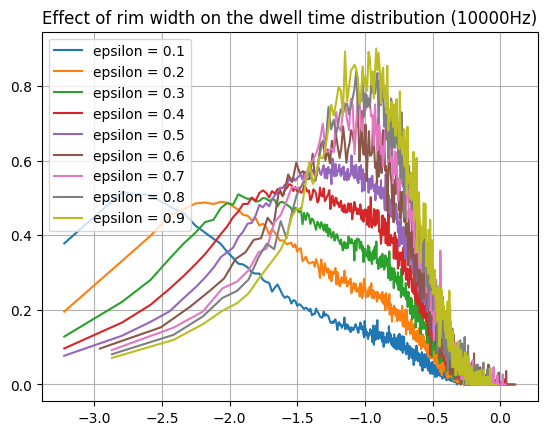

In [ ]:
Time=data0['dwell_time']
bin_edge0=np.arange(1/10000,np.max(Time),1/1000)
bin_center0 = (bin_edge0[:-1] + bin_edge0[1:]) / 2
accuracy=10
hist0,bin0= np.histogram(np.round(Time,decimals=accuracy), bins = np.round(bin_edge0,decimals=accuracy), density = True)
plt.plot(np.log10(bin_center0),bin_center0*np.log(10)*hist0, label='epsilon = 0.1')
Time=data1['dwell_time']
bin_edge0=np.arange(1/10000,np.max(Time),1/1000)
bin_center0 = (bin_edge0[:-1] + bin_edge0[1:]) / 2
accuracy=10
hist1,bin1= np.histogram(np.round(Time,decimals=accuracy), bins = np.round(bin_edge0,decimals=accuracy), density = True)
plt.plot(np.log10(bin_center0),bin_center0*np.log(10)*hist1, label='epsilon = 0.2')
Time=data2['dwell_time']
bin_edge0=np.arange(1/10000,np.max(Time),1/1000)
bin_center0 = (bin_edge0[:-1] + bin_edge0[1:]) / 2
accuracy=10
hist2,bin2= np.histogram(np.round(Time,decimals=accuracy), bins = np.round(bin_edge0,decimals=accuracy), density = True)
plt.plot(np.log10(bin_center0),bin_center0*np.log(10)*hist2, label='epsilon = 0.3')
Time=data3['dwell_time']
bin_edge0=np.arange(1/10000,np.max(Time),1/1000)
bin_center0 = (bin_edge0[:-1] + bin_edge0[1:]) / 2
accuracy=10
hist3,bin3= np.histogram(np.round(Time,decimals=accuracy), bins = np.round(bin_edge0,decimals=accuracy), density = True)
plt.plot(np.log10(bin_center0),bin_center0*np.log(10)*hist3, label='epsilon = 0.4')
Time=data4['dwell_time']
bin_edge0=np.arange(1/10000,np.max(Time),1/1000)
bin_center0 = (bin_edge0[:-1] + bin_edge0[1:]) / 2
accuracy=10
hist4,bin4= np.histogram(np.round(Time,decimals=accuracy), bins = np.round(bin_edge0,decimals=accuracy), density = True)
plt.plot(np.log10(bin_center0),bin_center0*np.log(10)*hist4, label='epsilon = 0.5')
Time=data5['dwell_time']
bin_edge0=np.arange(1/10000,np.max(Time),1/500)
bin_center0 = (bin_edge0[:-1] + bin_edge0[1:]) / 2
accuracy=10
hist5,bin5= np.histogram(np.round(Time,decimals=accuracy), bins = np.round(bin_edge0,decimals=accuracy), density = True)
plt.plot(np.log10(bin_center0),bin_center0*np.log(10)*hist5, label='epsilon = 0.6')
Time=data6['dwell_time']
bin_edge0=np.arange(1/10000,np.max(Time),1/400)
bin_center0 = (bin_edge0[:-1] + bin_edge0[1:]) / 2
accuracy=10
hist6,bin6= np.histogram(np.round(Time,decimals=accuracy), bins = np.round(bin_edge0,decimals=accuracy), density = True)
plt.plot(np.log10(bin_center0),bin_center0*np.log(10)*hist6, label='epsilon = 0.7')
Time=data7['dwell_time']
bin_edge0=np.arange(1/10000,np.max(Time),1/400)
bin_center0 = (bin_edge0[:-1] + bin_edge0[1:]) / 2
accuracy=10
hist7,bin7= np.histogram(np.round(Time,decimals=accuracy), bins = np.round(bin_edge0,decimals=accuracy), density = True)
plt.plot(np.log10(bin_center0),bin_center0*np.log(10)*hist7, label='epsilon = 0.8')
Time=data8['dwell_time']
bin_edge0=np.arange(1/10000,np.max(Time),1/400)
bin_center0 = (bin_edge0[:-1] + bin_edge0[1:]) / 2
accuracy=10
hist8,bin8= np.histogram(np.round(Time,decimals=accuracy), bins = np.round(bin_edge0,decimals=accuracy), density = True)
plt.plot(np.log10(bin_center0),bin_center0*np.log(10)*hist8, label='epsilon = 0.9')
plt.title('Effect of rim width on the dwell time distribution (10000Hz)')
plt.legend()
plt.grid()                                                                                                  

In [52]:
path0 = './Excel/1.005_30Hz_depth=0step_size=0.04_angle_wander.xlsx'
data0 = pd.read_excel(path0, sheet_name='dwell time')

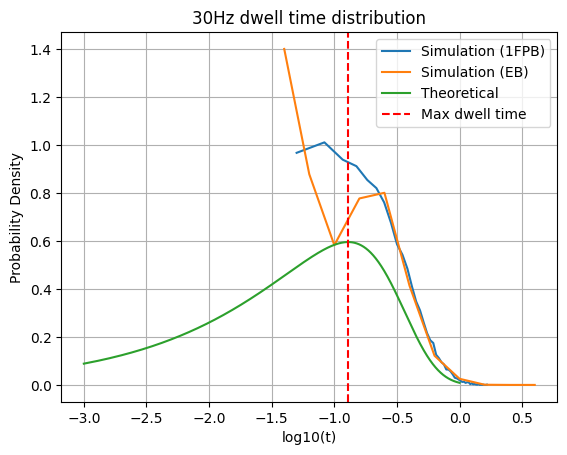

In [54]:
accuracy=10
Time0=data0['dwell_time']
bin_edge0=np.arange(1/30,np.max(Time0),1/30)
bin_center0 = (bin_edge0[:-1] + bin_edge0[1:]) / 2
hist0,bin0= np.histogram(np.round(Time0,decimals=accuracy), bins =np.round(bin_edge0,decimals=accuracy),density=True)
plt.plot(np.log10(bin_center0),bin_center0*hist0*np.log(10), label='Simulation (1FPB)')
bin_edge0=np.arange(-1.5,0.9,0.2)
bin_center0 = (bin_edge0[:-1] + bin_edge0[1:]) / 2
Time0=data0['dwell_time']
hist0,bin0= np.histogram(np.log10(Time0), bins = bin_edge0,density=True)
plt.plot(bin_center0,hist0, label='Simulation (EB)')
unit= r_out**2/D
t=np.linspace(0.001, 1, 10000)
x=np.log10(t)
y=dwell(t/unit)/unit*t*np.log(10)
plt.plot(x, y, label='Theoretical')
plt.title("30Hz dwell time distribution")
plt.xlabel("log10(t)")
plt.ylabel('Probability Density')
x_max=x[np.argmax(y)]
plt.axvline(x_max, color='red', linestyle='--', label='Max dwell time')
plt.grid()
plt.legend()